# Violin plot — redshift distribution

Swift catalogue (ground truth) vs VQR EfficientSU2 predictions for L=1, 2, 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

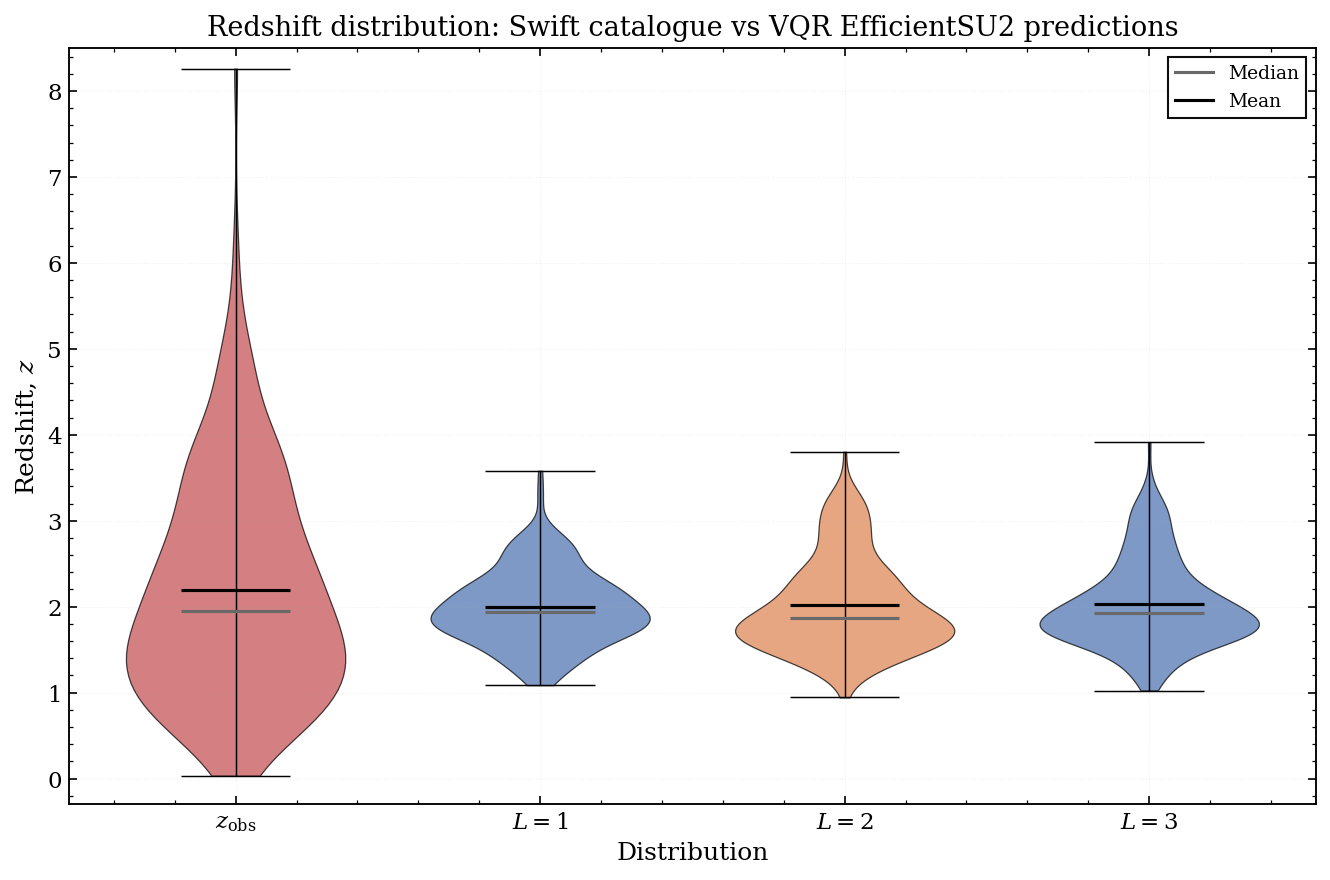

Saved: fig_violin_redshift_distributions.png

Wasserstein-1 distance to z_obs:
  L=1: W1 = 0.694
  L=2: W1 = 0.621
  L=3: W1 = 0.656


In [7]:


plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'axes.linewidth': 0.9, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.major.size': 4, 'ytick.major.size': 4,
    'legend.fontsize': 9.5, 'legend.frameon': True,
    'legend.framealpha': 0.95, 'legend.edgecolor': 'black',
    'legend.fancybox': False, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.20,
    'grid.linestyle': ':', 'grid.linewidth': 0.5,
})

C_OBS = '#C44E52'
C_L1  = '#4C72B0'
C_L2  = '#DD8452'
C_L3  = '#4C72B0'

df    = pd.read_csv('vqr7q_predictions.csv')
z_obs = df['y_true_z'].unique()
preds = {}
for L in [1, 2, 3]:
    sub      = df[df['n_layers'] == L]
    preds[L] = sub.groupby('y_true_z')['y_pred_z'].mean().values

labels    = [r'$z_{\rm obs}$', r'$L=1$', r'$L=2$', r'$L=3$']
data      = [z_obs, preds[1], preds[2], preds[3]]
colors    = [C_OBS, C_L1, C_L2, C_L3]
positions = [1, 2, 3, 4]

fig, ax = plt.subplots(figsize=(9, 6))

vp = ax.violinplot(data, positions=positions, widths=0.72,
                   showmeans=True, showmedians=True, showextrema=True)

for pc, color in zip(vp['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.6)
    pc.set_alpha(0.72)

vp['cmeans'].set_color('black');     vp['cmeans'].set_linewidth(1.5)
vp['cmedians'].set_color('dimgray'); vp['cmedians'].set_linewidth(1.5)
for k in ['cbars', 'cmins', 'cmaxes']:
    vp[k].set_color('black'); vp[k].set_linewidth(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel(r'Redshift, $z$')
ax.set_xlabel('Distribution')
ax.set_title(r'Redshift distribution: Swift catalogue vs VQR EfficientSU2 predictions')
ax.set_ylim(-0.3, 8.5)
ax.minorticks_on()

legend = [
    plt.Line2D([0],[0], color='dimgray',   lw=1.5,   label='Median'),
    plt.Line2D([0],[0], color='black', lw=1.5, label='Mean'),
]
ax.legend(handles=legend, loc='upper right', fontsize=9)

plt.tight_layout()
fname = 'fig_violin_redshift_distributions.png'
plt.savefig(fname, dpi=300)
plt.show()
print(f'Saved: {fname}')

# Wasserstein-1 distances
from scipy.stats import wasserstein_distance
print('\nWasserstein-1 distance to z_obs:')
for L in [1,2,3]:
    print(f'  L={L}: W1 = {wasserstein_distance(z_obs, preds[L]):.3f}')

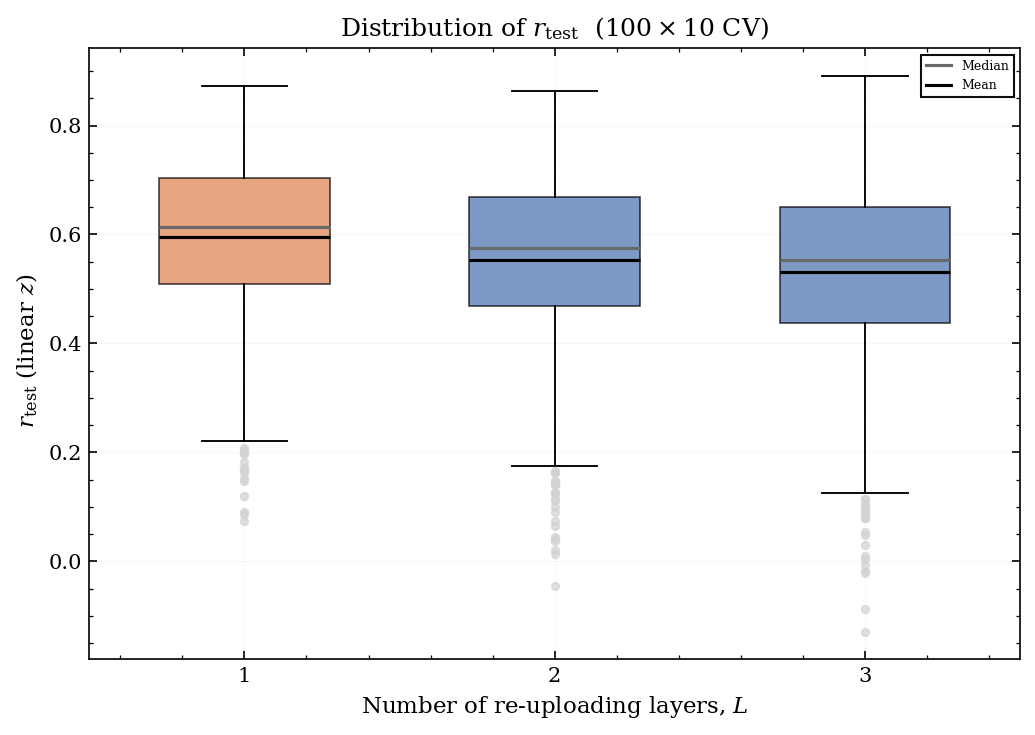

Saved: fig_boxplot_layers.png

──────────────────────────────────────────────────────────
L          N    Mean   Median     Std      Q1      Q3
──────────────────────────────────────────────────────────
1       1000   0.596    0.613   0.143   0.509   0.704 *
2       1000   0.554    0.576   0.155   0.469   0.670
3       1000   0.532    0.553   0.161   0.437   0.650


In [3]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
})

# ── Colores ───────────────────────────────────────────────────────
C_OPT   = '#DD8452'   # naranja — L=2 (modelo óptimo)
C_OTHER = '#4C72B0'    # azul    — L=1, L=3
C_FLIER = 'lightgray'

# ── Cargar datos ──────────────────────────────────────────────────
df = pd.read_csv('vqr7q_cv_detail.csv')

layers = sorted(df['n_layers'].unique())   # [1, 2, 3]
data   = [df[df['n_layers'] == L]['r_test_z'].dropna().values for L in layers]

# ── Figura ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(
    data,
    positions    = layers,
    widths       = 0.55,
    patch_artist = True,
    showmeans    = True,
    meanline     = True,          # ← esta línea es la que faltaba
    showfliers   = True,
    medianprops  = dict(color='dimgray',   linestyle='-', linewidth=1.5),
    meanprops    = dict(color='black', linestyle='-', linewidth=1.5),
    flierprops   = dict(marker='o', markersize=3.5,
                        markerfacecolor=C_FLIER,
                        markeredgecolor=C_FLIER, alpha=0.7),
    whiskerprops = dict(linewidth=0.9),
    capprops     = dict(linewidth=0.9),
    boxprops     = dict(linewidth=0.8),
)
# Colorear cajas
for i, (patch, L) in enumerate(zip(bp['boxes'], layers)):
    color = C_OPT if L == 1 else C_OTHER
    patch.set_facecolor(color)
    patch.set_alpha(0.72)

ax.set_xlabel(r'Number of re-uploading layers, $L$')
ax.set_ylabel(r' $r_{\mathrm{test}}$ (linear $z$)')
ax.set_title(
    r'Distribution of $r_{\mathrm{test}}$  '
    r'($100\times10$ CV)'
)
ax.set_xticks(layers)
ax.minorticks_on()

# Leyenda
legend_elements = [
    plt.Line2D([0],[0], color='dimgray',   linewidth=1.5, label='Median'), 
    plt.Line2D([0],[0], color='black', linewidth=1.5, label='Mean'), 
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=6)

plt.tight_layout()
fname = 'fig_boxplot_layers.png'
plt.savefig(fname, dpi=300)
plt.show()
print(f'Saved: {fname}')

# ── Resumen estadístico ───────────────────────────────────────────
print(f'\n{"":─<58}')
print(f'{"L":<5} {"N":>6} {"Mean":>7} {"Median":>8} '
      f'{"Std":>7} {"Q1":>7} {"Q3":>7}')
print(f'{"":─<58}')
for L, d in zip(layers, data):
    mark = ' *' if L == 1 else ''
    print(f'{L:<5} {len(d):>6} {np.mean(d):>7.3f} '
          f'{np.median(d):>8.3f} {np.std(d):>7.3f} '
          f'{np.percentile(d,25):>7.3f} '
          f'{np.percentile(d,75):>7.3f}{mark}')

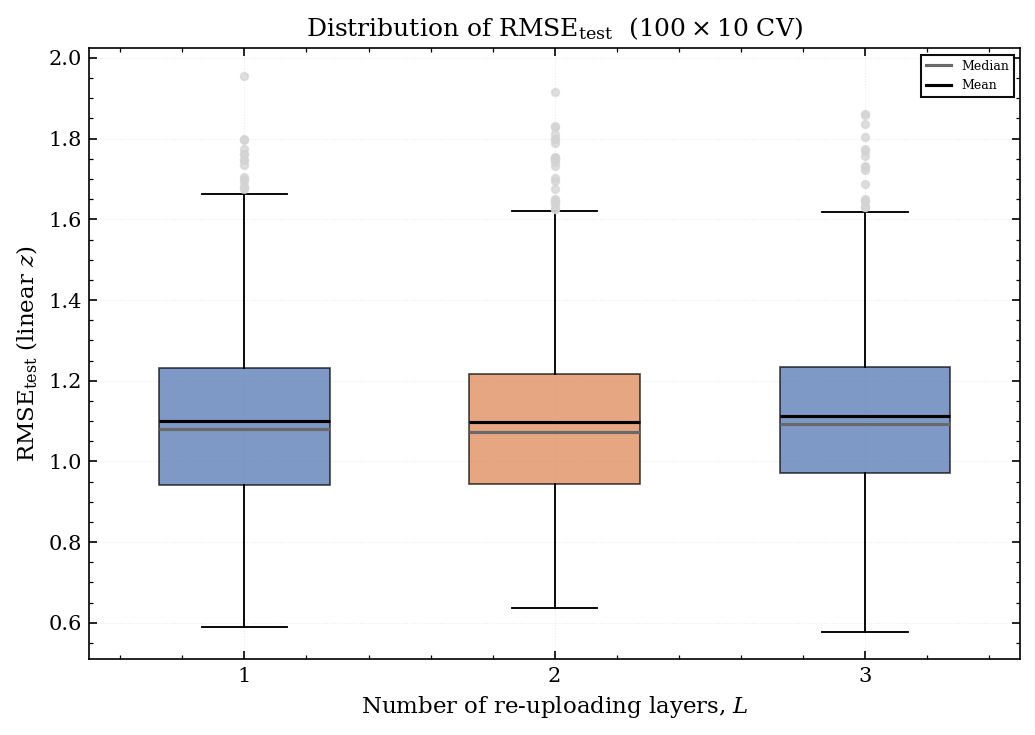

In [5]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
})

C_OPT   = '#DD8452'
C_OTHER = '#4C72B0'
C_FLIER = 'lightgray'

df     = pd.read_csv('vqr7q_cv_detail.csv')
layers = sorted(df['n_layers'].unique())
data   = [df[df['n_layers'] == L]['RMSE_test_z'].dropna().values
          for L in layers]

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(
    data,
    positions    = layers,
    widths       = 0.55,
    patch_artist = True,
    showmeans    = True,
    meanline     = True,
    showfliers   = True,
    medianprops  = dict(color='dimgray',   linestyle='-', linewidth=1.5),
    meanprops    = dict(color='black', linestyle='-', linewidth=1.5),
    flierprops   = dict(marker='o', markersize=3.5,
                        markerfacecolor=C_FLIER,
                        markeredgecolor=C_FLIER, alpha=0.7),
    whiskerprops = dict(linewidth=0.9),
    capprops     = dict(linewidth=0.9),
    boxprops     = dict(linewidth=0.8),
)

for patch, L in zip(bp['boxes'], layers):
    patch.set_facecolor(C_OPT if L == 2 else C_OTHER)
    patch.set_alpha(0.72)

ax.set_xlabel(r'Number of re-uploading layers, $L$')
ax.set_ylabel(r'RMSE$_{\mathrm{test}}$ (linear $z$)')
ax.set_title(r'Distribution of RMSE$_{\mathrm{test}}$  ($100\times10$ CV)')
ax.set_xticks(layers)
ax.minorticks_on()

legend_elements = [
    plt.Line2D([0],[0], color='dimgray',   linewidth=1.5, label='Median'),
    plt.Line2D([0],[0], color='black', linewidth=1.5, label='Mean'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=6)

plt.tight_layout()
plt.savefig('fig_boxplot_RMSE.png', dpi=300)
plt.show()

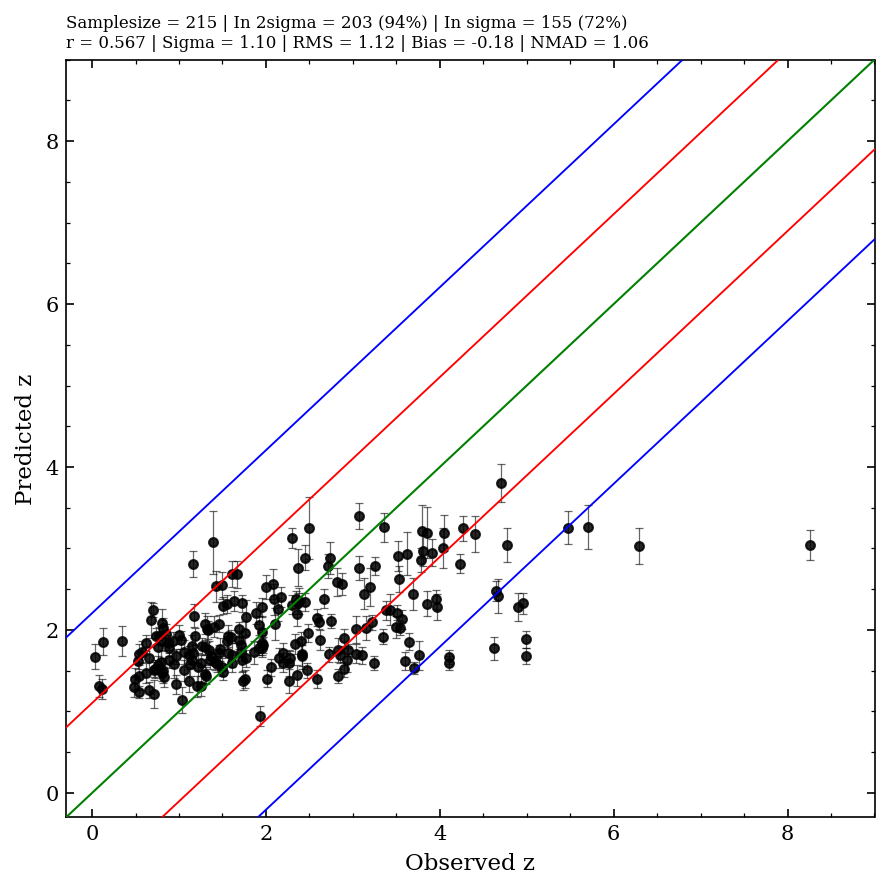

In [9]:


plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9,
    'axes.labelsize': 11,
    'axes.titlesize': 9,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
})

# ── Datos ─────────────────────────────────────────────────────────
df  = pd.read_csv('vqr7q_predictions.csv')
L2  = df[df['n_layers'] == 2]
grb = L2.groupby('y_true_z')['y_pred_z'].agg(['mean', 'std']).reset_index()
grb.columns = ['z_obs', 'z_pred', 'z_std']
grb['z_std'] = grb['z_std'].fillna(0)

z_obs  = grb['z_obs'].values
z_pred = grb['z_pred'].values
z_std  = grb['z_std'].values

# ── Estadísticas (header igual que Narendra) ──────────────────────
r,  _  = pearsonr(z_obs, z_pred)
rmse   = np.sqrt(np.mean((z_obs - z_pred)**2))
bias   = np.mean(z_pred - z_obs)
sigma  = np.std(z_pred - z_obs)
nmad   = 1.4826 * np.median(np.abs(
             (z_pred - z_obs) - np.median(z_pred - z_obs)))
n      = len(z_obs)
n1     = int((np.abs(z_pred - z_obs) < sigma).sum())
n2     = int((np.abs(z_pred - z_obs) < 2*sigma).sum())
pct1   = 100 * n1 / n
pct2   = 100 * n2 / n

# ── Figura ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

LIMS = [-0.3, 9.0]

# Barras de error (std entre folds)
ax.errorbar(z_obs, z_pred, yerr=z_std,
            fmt='none', ecolor='black', elinewidth=0.6,
            capsize=2, capthick=0.6, alpha=0.6, zorder=2)

# Puntos
ax.scatter(z_obs, z_pred,
           s=18, color='black', zorder=3, alpha=0.85)

# Línea 1:1 (verde)
ax.plot(LIMS, LIMS,
        color='green', lw=1.0, zorder=4)

# Bandas 1σ (rojo) y 2σ (azul)
z_line = np.array(LIMS)
ax.plot(z_line, z_line + sigma,   color='red',  lw=0.9, ls='-', zorder=4)
ax.plot(z_line, z_line - sigma,   color='red',  lw=0.9, ls='-', zorder=4)
ax.plot(z_line, z_line + 2*sigma, color='blue', lw=0.9, ls='-', zorder=4)
ax.plot(z_line, z_line - 2*sigma, color='blue', lw=0.9, ls='-', zorder=4)

ax.set_xlim(LIMS)
ax.set_ylim(LIMS)
ax.set_xlabel('Observed z')
ax.set_ylabel('Predicted z')
ax.minorticks_on()

# Header (dos líneas como en Narendra)
header1 = (f'Samplesize = {n}'
           f' | In 2sigma = {n2} ({pct2:.0f}%)'
           f' | In sigma = {n1} ({pct1:.0f}%)')
header2 = (f'r = {r:.3f}'
           f' | Sigma = {sigma:.2f}'
           f' | RMS = {rmse:.2f}'
           f' | Bias = {bias:.2f}'
           f' | NMAD = {nmad:.2f}')

ax.set_title(f'{header1}\n{header2}', fontsize=8, loc='left', pad=6)

plt.tight_layout()
plt.savefig('fig_scatter_narendra_style_L2.png', dpi=300)
plt.show()

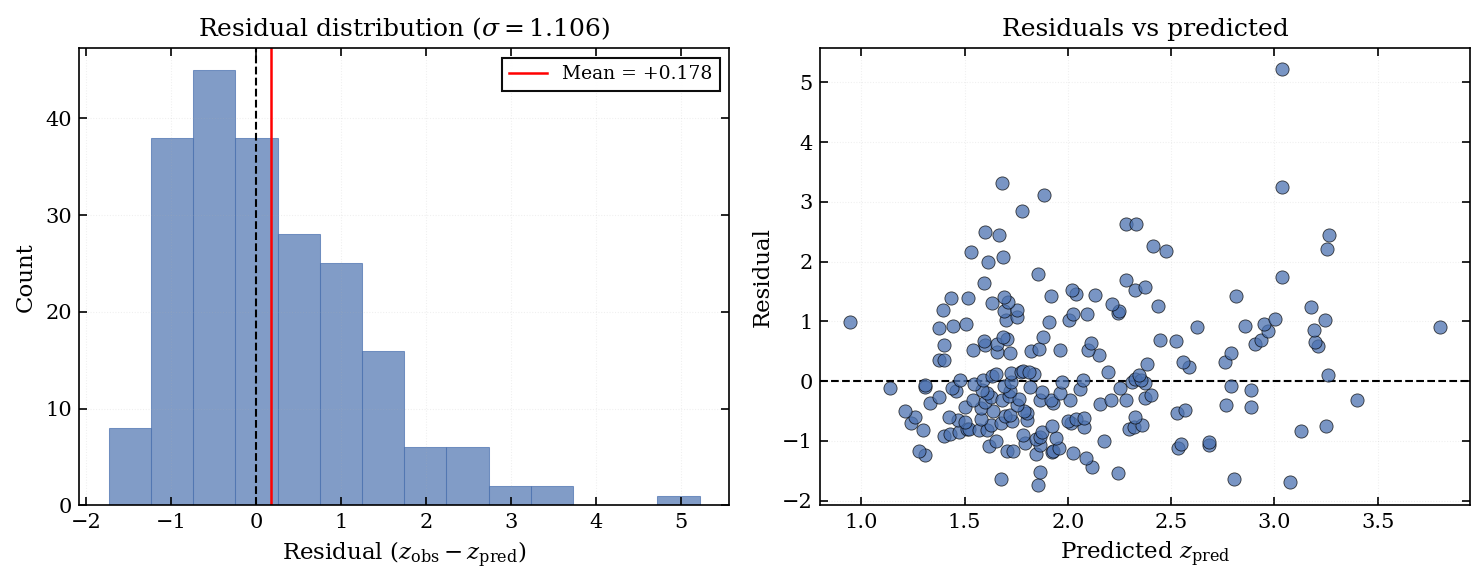

Saved: fig_residuals_OOF_L2.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.20,
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
})

# ── Datos OOF ─────────────────────────────────────────────────────
LAYER = 2

df  = pd.read_csv('vqr7q_predictions.csv')
sub = df[df['n_layers'] == LAYER]
grb = sub.groupby('y_true_z')['y_pred_z'].agg(['mean']).reset_index()
grb.columns = ['z_obs', 'z_pred']

residuals = grb['z_obs'] - grb['z_pred']
sigma     = residuals.std()
mean_res  = residuals.mean()

# ── Figura ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Panel izquierdo: histograma de residuos ───────────────────────
axes[0].hist(residuals, bins=14,
             color='#4C72B0', alpha=0.7,
             edgecolor='#4C72B0', linewidth=0.5)
axes[0].axvline(0,         color='black', ls='--', lw=1.0)
axes[0].axvline(mean_res,  color='red',   ls='-',  lw=1.2,
                label=f'Mean = {mean_res:+.3f}')
axes[0].set_xlabel(r'Residual ($z_{\rm obs} - z_{\rm pred}$)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residual distribution ($\\sigma={sigma:.3f}$)')
axes[0].legend(loc='upper right')

# ── Panel derecho: residuos vs z_pred ────────────────────────────
axes[1].scatter(grb['z_pred'], residuals,
                s=40, alpha=0.75,
                color='#4C72B0',
                edgecolor='black', linewidths=0.4, zorder=3)
axes[1].axhline(0, color='black', ls='--', lw=1.0)
axes[1].set_xlabel(r'Predicted $z_{\rm pred}$')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs predicted')

plt.tight_layout()
fname = f'fig_residuals_OOF_L{LAYER}.png'
plt.savefig(fname, dpi=300)
plt.show()
print(f'Saved: {fname}')